In [65]:
import os
os.environ["KERAS_BACKEND"] = "jax"

import keras, datetime
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from src.model.assemble_model import build_reg_model
from src.model.miscellaneous import create_seq_dataset_multiple_input_single_output
from sklearn.metrics import r2_score

In [ ]:
file_name_list = sorted(os.listdir('data'))  # index 번호가 실행 환경에 따라 달라지지 않도록 정렬

data_list = []

for i, file_name in enumerate(file_name_list):
    data = pd.read_csv('data/' + file_name)
    data['index'] = i
    data_list.append(data)

data = pd.concat(data_list)
data.reset_index(drop=True, inplace=True)

print(file_name_list)

In [ ]:
data = data[data['Status'] == 'TEST']
data.reset_index(drop=True, inplace=True)

In [4]:
data

,Time(s),Pressure(bar),Leak(cm3/min),Status,index
0,58.0,1.0,5.330,TEST,0
1,58.1,1.0,5.276,TEST,0
2,58.2,1.0,5.223,TEST,0
3,58.3,1.0,5.170,TEST,0
4,58.4,1.0,5.118,TEST,0
...,...,...,...,...,...
1311,89.6,1.0,-2.714,TEST,3
1312,89.7,1.0,-2.768,TEST,3
1313,89.8,1.0,-2.822,TEST,3
1314,89.9,1.0,-2.876,TEST,3


In [ ]:
flow_rate_df = data['Leak(cm3/min)']

Text(0, 0.5, 'Flow-Rate(cm3/min)')

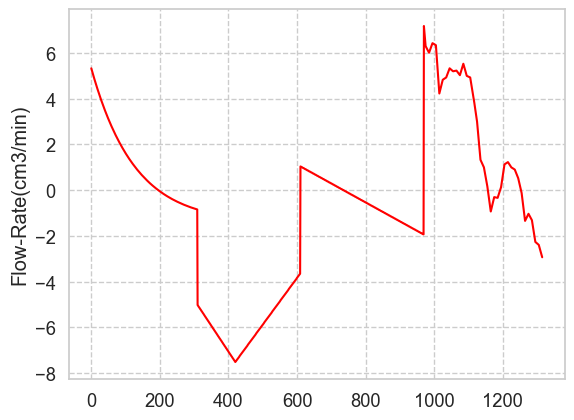

In [6]:
sns.set_theme(font_scale=1.2)
sns.set_style('whitegrid', {'grid.linestyle': '--'})

sns.lineplot(data=flow_rate_df, color='red')

plt.ylabel('Flow-Rate(cm3/min)')

Text(0.5, 0, 'Flow-Rate(cm3/min)')

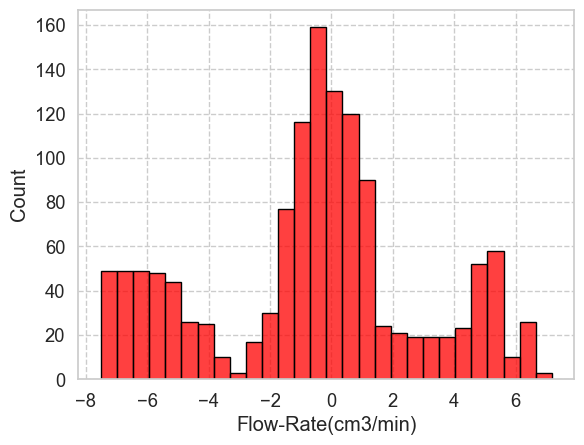

In [7]:
sns.set_theme(font_scale=1.2)
sns.set_style('whitegrid', {'grid.linestyle': '--'})

sns.histplot(flow_rate_df, color='red', edgecolor='black')

plt.xlabel('Flow-Rate(cm3/min)')

In [ ]:
seq_len = 30
pred_distance = 100

val_file_idx = len(file_name_list) - 1  # 마지막 파일 1개를 검증용으로 떼어 둔다

# 파일마다 별도의 검사 사이클이므로 시퀀스도 파일 단위로 만든다.
# 전체를 이어 붙인 뒤 시퀀스를 만들면 파일 경계를 넘는 샘플(앞 검사의 과거 + 뒤 검사의 정답)이 생긴다.
feature_per_file, target_per_file = [], []

for file_idx in sorted(data['index'].unique()):
    flow_rate_arr = data.loc[data['index'] == file_idx, 'Leak(cm3/min)'].to_numpy().reshape(-1, 1)
    flow_rate_arr = np.concatenate([flow_rate_arr, flow_rate_arr], axis=1)

    feature, target = create_seq_dataset_multiple_input_single_output(data=flow_rate_arr, seq_len=seq_len,
                                                                     pred_distance=pred_distance, target_idx_pos=1)

    feature_per_file.append(feature)
    target_per_file.append(target)

train_feature = np.concatenate([f for i, f in enumerate(feature_per_file) if i != val_file_idx])
train_target = np.concatenate([t for i, t in enumerate(target_per_file) if i != val_file_idx])

val_feature = feature_per_file[val_file_idx]
val_target = target_per_file[val_file_idx]

print('train:', train_feature.shape, train_target.shape)
print('val  :', val_feature.shape, val_target.shape, f'(file: {file_name_list[val_file_idx]})')

In [ ]:
model = build_reg_model(input_shape=(train_feature.shape[1:]), d_dims=64, dropout_rate=0.5, learning_rate=0.001)
model.summary()

In [ ]:
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=500, verbose=0)
csv_logger = keras.callbacks.CSVLogger(filename=f'log_{pred_distance}_model.csv', append=False, separator=',')
model_chk_point = keras.callbacks.ModelCheckpoint(filepath=f'model_{pred_distance}.keras', monitor="val_loss", verbose=2,
                                                  save_best_only=True, save_weights_only=False, mode="min", save_freq="epoch", initial_value_threshold=None)

log_dir = "logs/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)


model.fit(x=train_feature, y=train_target, validation_data=(val_feature, val_target),
          epochs=999999, batch_size=200, verbose=0, callbacks=[early_stop, csv_logger, model_chk_point])

In [ ]:
result = pd.read_csv(f'log_{pred_distance}_model.csv')
result

In [ ]:
sns.set_theme(font_scale=1.2)
sns.set_style('whitegrid', {'grid.linestyle': '--'})

sns.lineplot(result['loss'], color='red')


plt.xlabel('Epoch')

plt.ylim(0.1, 10)
plt.yscale('log')


In [ ]:
model = keras.models.load_model(f'model_{pred_distance}.keras')

In [ ]:
train_pred = np.squeeze(model.predict(train_feature))
val_pred = np.squeeze(model.predict(val_feature))

In [ ]:
sns.set_theme(font_scale=1.2)
sns.set_style('whitegrid', {'grid.linestyle': '--'})

sns.scatterplot(x=np.squeeze(val_target), y=val_pred, color='red', edgecolor='black')

plt.xlabel('Ground Truth Flow-Rate(cm3/min)')
plt.ylabel('Predicted Flow-Rate(cm3/min)')
plt.title('Validation set')

In [ ]:
abs_error = np.abs(val_pred - np.squeeze(val_target))
rela_error = abs_error/np.abs((np.squeeze(val_target))+0.001)
rela_error*=100

In [ ]:
print('validation MAE:', np.mean(abs_error), '/ MAPE(%):', np.mean(rela_error))

train_abs_error = np.abs(train_pred - np.squeeze(train_target))
print('train      MAE:', np.mean(train_abs_error))

In [ ]:
print('validation R2:', r2_score(np.squeeze(val_target), val_pred))
print('train      R2:', r2_score(np.squeeze(train_target), train_pred))

In [ ]:
sns.set_theme(font_scale=1.2)
sns.set_style('whitegrid', {'grid.linestyle': '--'})

sns.lineplot(np.squeeze(val_target), color='green', label='Ground Truth')
sns.lineplot(val_pred, color='red', label='Predicted')

plt.title('Validation set')

In [ ]:
sns.set_theme(font_scale=1.2)
sns.set_style('whitegrid', {'grid.linestyle': '--'})

sns.scatterplot(x=np.squeeze(val_target), y=abs_error, color='red', edgecolor='black')

plt.xlabel('Ground Truth Flow-Rate(cm3/min)')
plt.ylabel('Absolute Error(cm3/min)')
plt.yscale('log')
plt.title('Validation set')

In [ ]:
sns.set_theme(font_scale=1.2)
sns.set_style('whitegrid', {'grid.linestyle': '--'})

sns.scatterplot(x=np.squeeze(val_target), y=rela_error, color='red', edgecolor='black')

plt.xlabel('Ground Truth Flow-Rate(cm3/min)')
plt.ylabel('Relative Error(%)')
plt.yscale('log')
plt.title('Validation set')